# Run algorithm on COVID data

CovSpectrum is used to get current Covid variants in a timeframe between 14.10.24 to 16.04.25.

As a first try they are grouped by nextstrain clade. The recombinant variants are filtered out by now, because they are not expected to have the standard exponential growth behavior.

At the start of the pandemic the population was fairly homogeneous. However, throughout the course of the pandemic people had different infection and vaccination patterns and the population became more homogeneous which indicates the the exponential model fits better to the start of the pandemic.

In [1]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import plotly.colors

from viral_variant_comp.plotting import plot_viral_composition_dual, plot_heatmap, plot_viral_composition_interactive
from viral_variant_comp.estimate import calculate_cooccurence
from viral_variant_comp.simulate_count_data import preprocess_covid_data
from viral_variant_comp.estimate import BFGSCompositionEstimator, StepwiseBFGSCompositionEstimator, EvofrCompositionEstimator

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


url_switzerland = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?country=Switzerland&dateFrom=2024-10-14&dateTo=2025-04-09&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date"
url_world = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?&dateFrom=2024-10-14&dateTo=2025-04-09&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date,country"
url_usa = "https://lapis.cov-spectrum.org/gisaid/v2/sample/aggregated?country=USA&dateFrom=2020-01-01&dateTo=2025-04-16&host=Human&accessKey=9Cb3CqmrFnVjO3XCxQLO6gUnKPd&fields=nextcladePangoLineage,date,nextstrainClade"
response = requests.get(url_usa)

response.raise_for_status() # Raise an error if the request failed
data = response.json()  # Parse the JSON content
counts_df = pd.DataFrame(data['data'])
counts_df.to_csv("data/counts_covid_usa.csv", index=False)

counts_df.head()

In [2]:
counts_df = pd.read_csv("data/counts_covid_usa.csv")
counts_df.head()

,count,date,nextcladePangoLineage,nextstrainClade
0,2,2024-01-12,HK.20.1,23F
1,1,2024-01-25,HK.13,23F
2,2,2024-01-07,JR.1.1,23F
3,1,2024-01-18,EG.5.1.16,23F
4,1,2024-01-02,DV.7.1.4,23C


In [5]:
counts_df.sort_values('date')

,count,date,nextcladePangoLineage,nextstrainClade
194777,1,2020-01-04,B.1.2,20G
198148,1,2020-01-05,BA.1,21K
30956,1,2020-01-17,B.1,20A
126137,7,2020-01-19,A,19B
49181,1,2020-01-20,JN.1,24A
...,...,...,...,...
120072,1,2025-04-07,MC.10.1.7,24E
96872,2,2025-04-07,LP.8.1.1,25A
29845,1,2025-04-07,NW.1,25A
161632,2,2025-04-08,LP.8.1.1,25A


In [8]:
counts_df.date.value_counts().sort_index()

date
2020-01-04    1
2020-01-05    1
2020-01-17    1
2020-01-19    1
2020-01-20    1
             ..
2025-04-05    3
2025-04-06    9
2025-04-07    6
2025-04-08    1
2025-04-09    1
Name: count, Length: 1897, dtype: int64

In [3]:
data = preprocess_covid_data(counts_df)

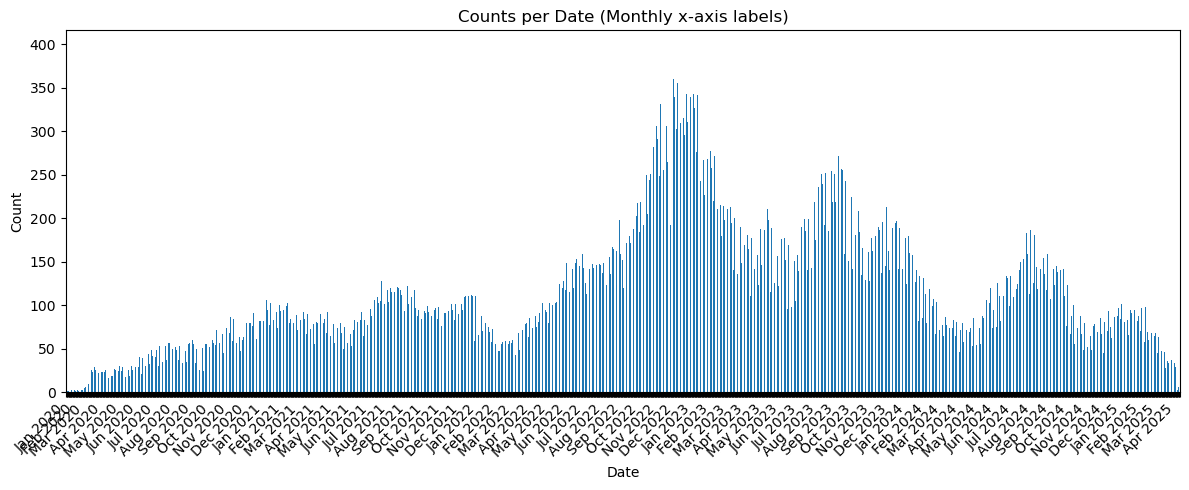

In [14]:
# Count values per date and sort
date_counts = data['counts_df']['date'].value_counts().sort_index()

# Plot
ax = date_counts.plot(kind='bar', figsize=(12, 5))

# Format x-axis ticks: keep only one tick per month
xticks = ax.get_xticks()
xticklabels = [label.get_text() for label in ax.get_xticklabels()]
dates = pd.to_datetime(xticklabels, errors='coerce')

# Replace x-axis labels with month-start labels only
new_labels = []
last_month = None
for d in dates:
    if pd.isna(d):
        new_labels.append("")
    elif d.month != last_month:
        new_labels.append(d.strftime("%b %Y"))  # e.g., "Apr 2025"
        last_month = d.month
    else:
        new_labels.append("")

ax.set_xticklabels(new_labels, rotation=45, ha='right')
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Counts per Date (Monthly x-axis labels)')
plt.tight_layout()
plt.show()

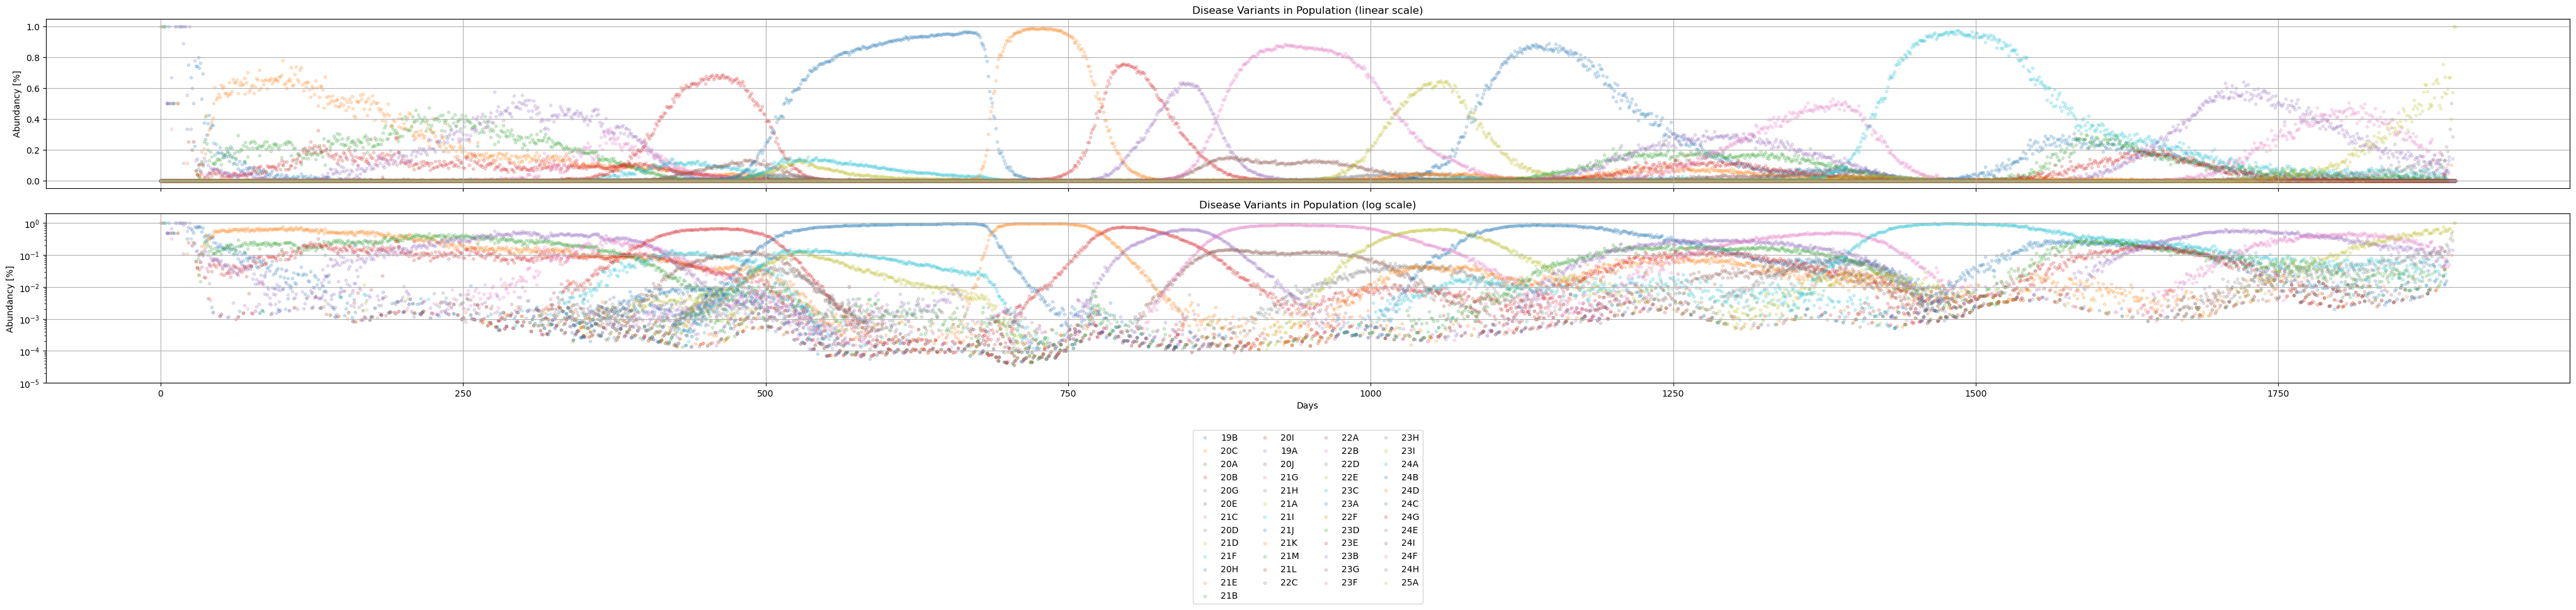

In [15]:
plot_viral_composition_dual(data['counts'], var_names=data['variant_names'], y_range = (1e-5, 2))
plot_viral_composition_interactive(data['counts'], var_names=data['variant_names'], logscale = False)

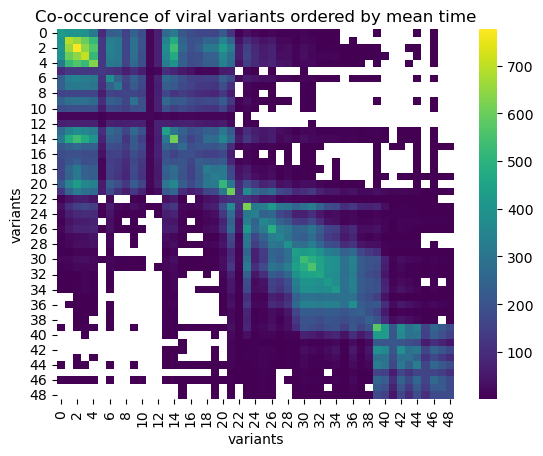

In [16]:
co_occurence_reorderd = calculate_cooccurence(data['counts'])
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")

In [17]:
estimators = {
    "BFGS": BFGSCompositionEstimator(data['counts']),
    "StepwiseBFGS": StepwiseBFGSCompositionEstimator(data['counts'], partition_size=10, overlap_size=5),
    "Evofr": EvofrCompositionEstimator(data['counts'], iterations=1000000, learning_rate=4e-3)
}

results = {}

for name, est in estimators.items():
    print(f"\n⏳ Running estimator: {name}")
    est.fit()
    results[name] = est.get_results()

    plot_viral_composition_interactive(data['counts'],composition_estimate=results[name]['composition_estimate'], var_names=data['variant_names'], logscale = False)
    plot_viral_composition_dual(data['counts'], composition_estimate=results[name]['composition_estimate'], y_range = (1e-5, 2))


⏳ Running estimator: BFGS


TypeError: minimize() got an unexpected keyword argument 'disp'

Options to optimize numerical estimation:
- adaptable window size
- different numerical method
- change parameters for bfgs: gtol (tolerance at which algoritm terminates), norm (order of norm)
- parameters for Armijo condition rule and curvature condition rule
- choose different initial conditions
- choose intial hessian different from identity matrix (hess_inv_0)
- https://docs.scipy.org/doc/scipy/reference/optimize.minimize-bfgs.html

In [7]:
#counts_df = counts_df[counts_df.date < '2025-03-15']    # counts after this date have counts below 40

#possibly filter out variants with too less counts
#variant_counts = counts_df['nextcladePangoLineage'].value_counts()
#variants_to_keep = variant_counts[variant_counts >= 2].index
#counts_df = counts_df[counts_df['nextcladePangoLineage'].isin(variants_to_keep)]
